# Demo 2: Model Comparison with PneumoniaMNIST

This demo compares multiple classification algorithms on medical chest X-ray images. We'll use **PneumoniaMNIST**, a dataset of pediatric chest X-rays labeled as normal or showing pneumonia.

## Learning Objectives

By the end of this demo, you will be able to:

1. Load and explore medical image data from MedMNIST
2. Prepare image data for sklearn classifiers
3. Use cross-validation to compare models fairly
4. Evaluate and select the best model

## 0. Setup

In [1]:
%pip install -q medmnist scikit-learn xgboost matplotlib seaborn pandas numpy

Note: you may need to restart the kernel to use updated packages.


## 1. Load PneumoniaMNIST

PneumoniaMNIST contains 5,856 pediatric chest X-ray images (28x28 grayscale) with binary labels: normal (0) or pneumonia (1).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from medmnist import PneumoniaMNIST

# Download and load the dataset
train_dataset = PneumoniaMNIST(split='train', download=True)
val_dataset = PneumoniaMNIST(split='val', download=True)
test_dataset = PneumoniaMNIST(split='test', download=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"\nImage shape: {train_dataset.imgs[0].shape}")
print(f"Labels: 0 = Normal, 1 = Pneumonia")

Training samples: 4708
Validation samples: 524
Test samples: 624

Image shape: (28, 28)
Labels: 0 = Normal, 1 = Pneumonia


## 2. Explore the Data

Visualize sample X-rays from each class.

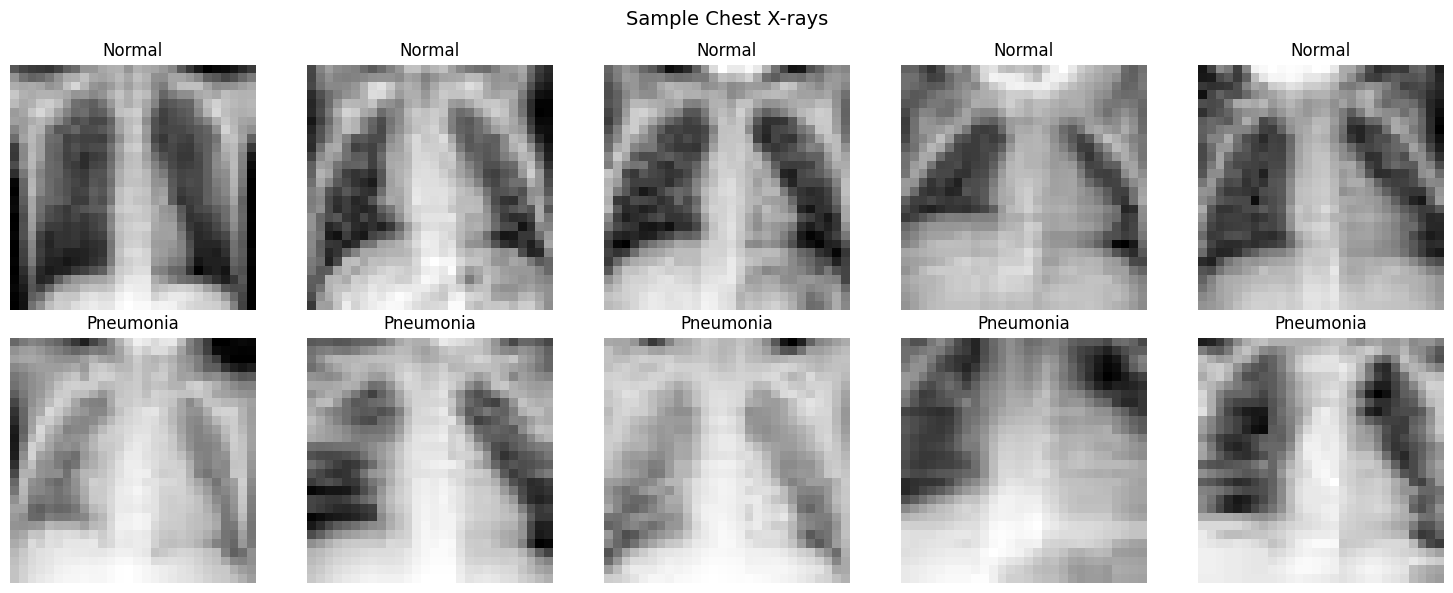


Class distribution (training):
  Normal: 1214 (25.8%)
  Pneumonia: 3494 (74.2%)


In [3]:
# Get images and labels
X_train_imgs = train_dataset.imgs
y_train = train_dataset.labels.squeeze()

# Plot sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Normal cases (top row)
normal_idx = np.where(y_train == 0)[0][:5]
for i, idx in enumerate(normal_idx):
    axes[0, i].imshow(X_train_imgs[idx].squeeze(), cmap='gray')
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')

# Pneumonia cases (bottom row)
pneumonia_idx = np.where(y_train == 1)[0][:5]
for i, idx in enumerate(pneumonia_idx):
    axes[1, i].imshow(X_train_imgs[idx].squeeze(), cmap='gray')
    axes[1, i].set_title('Pneumonia')
    axes[1, i].axis('off')

plt.suptitle('Sample Chest X-rays', fontsize=14)
plt.tight_layout()
plt.show()

# Class distribution
print("\nClass distribution (training):")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(['Normal', 'Pneumonia'], counts):
    print(f"  {label}: {count} ({count/len(y_train)*100:.1f}%)")

## 3. Prepare Data for Sklearn

Flatten 28x28 images to 784-dimensional vectors for traditional ML classifiers.

In [4]:
from sklearn.preprocessing import StandardScaler

# Flatten images: (N, 28, 28, 1) -> (N, 784)
X_train = train_dataset.imgs.reshape(len(train_dataset), -1).astype(np.float32)
X_val = val_dataset.imgs.reshape(len(val_dataset), -1).astype(np.float32)
X_test = test_dataset.imgs.reshape(len(test_dataset), -1).astype(np.float32)

y_train = train_dataset.labels.squeeze()
y_val = val_dataset.labels.squeeze()
y_test = test_dataset.labels.squeeze()

# Combine train + val for cross-validation
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")

Training features shape: (5232, 784)
Test features shape: (624, 784)


## 4. Cross-Validation for Model Comparison

Compare three classifiers using 5-fold stratified cross-validation.

In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, n_jobs=-1)
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model
print("5-Fold Cross-Validation Results (ROC AUC):\n")
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train_full, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  AUC per fold: {scores.round(3)}")
    print(f"  Mean AUC: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})\n")

5-Fold Cross-Validation Results (ROC AUC):



Logistic Regression:
  AUC per fold: [0.981 0.987 0.982 0.984 0.987]
  Mean AUC: 0.984 (+/- 0.005)



Random Forest:
  AUC per fold: [0.985 0.988 0.99  0.986 0.988]
  Mean AUC: 0.987 (+/- 0.003)



XGBoost:
  AUC per fold: [0.99  0.993 0.994 0.99  0.993]
  Mean AUC: 0.992 (+/- 0.003)



## 5. Train Final Models and Evaluate on Test Set

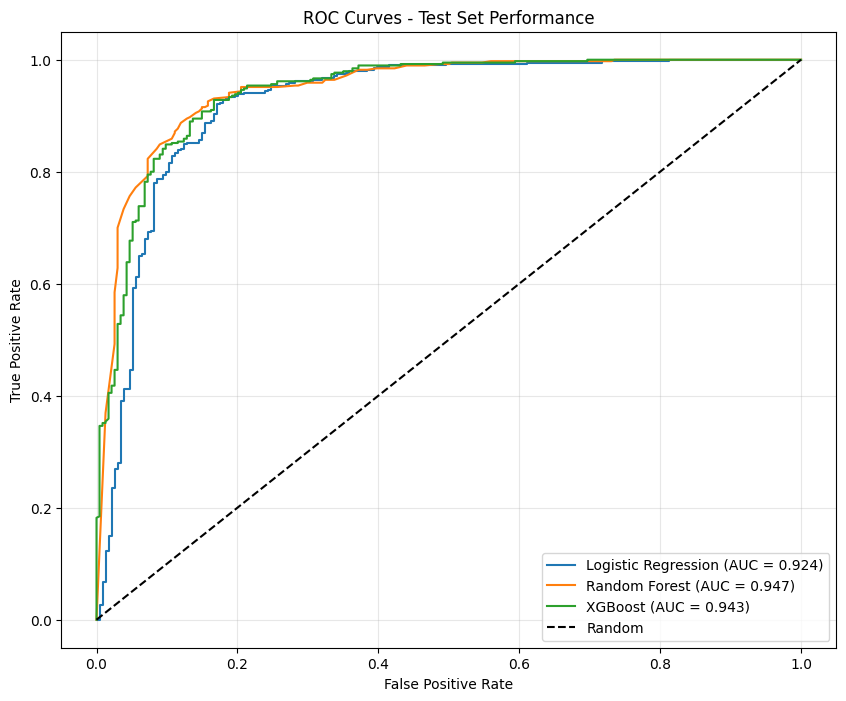


Logistic Regression - Test Set:
              precision    recall  f1-score   support

      Normal       0.96      0.59      0.73       234
   Pneumonia       0.80      0.99      0.88       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624


Random Forest - Test Set:
              precision    recall  f1-score   support

      Normal       0.95      0.63      0.76       234
   Pneumonia       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.82       624
weighted avg       0.87      0.85      0.84       624


XGBoost - Test Set:
              precision    recall  f1-score   support

      Normal       0.97      0.62      0.76       234
   Pneumonia       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.80      0.82    

In [6]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

# Train on full training set and evaluate on test set
results = {}
trained_models = {}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train_full)
    trained_models[name] = model

    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Store results
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'predictions': y_pred, 'probabilities': y_prob}

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set Performance')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

# Print classification reports
for name, result in results.items():
    print(f"\n{name} - Test Set:")
    print(classification_report(y_test, result['predictions'],
                                target_names=['Normal', 'Pneumonia']))

## 6. Confusion Matrix for Best Model

Best model: Random Forest


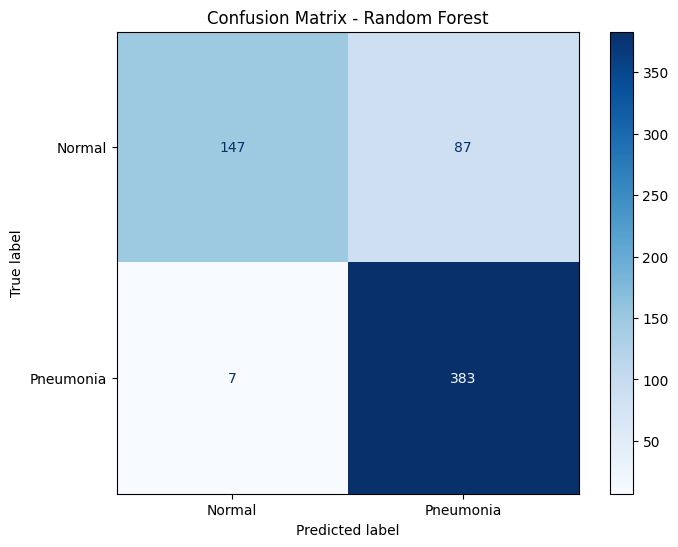

In [7]:
# Find best model
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"Best model: {best_model_name}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, best_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Pneumonia'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()

## 7. Feature Importance (Random Forest)

Use built-in feature importances to see which pixels matter most.

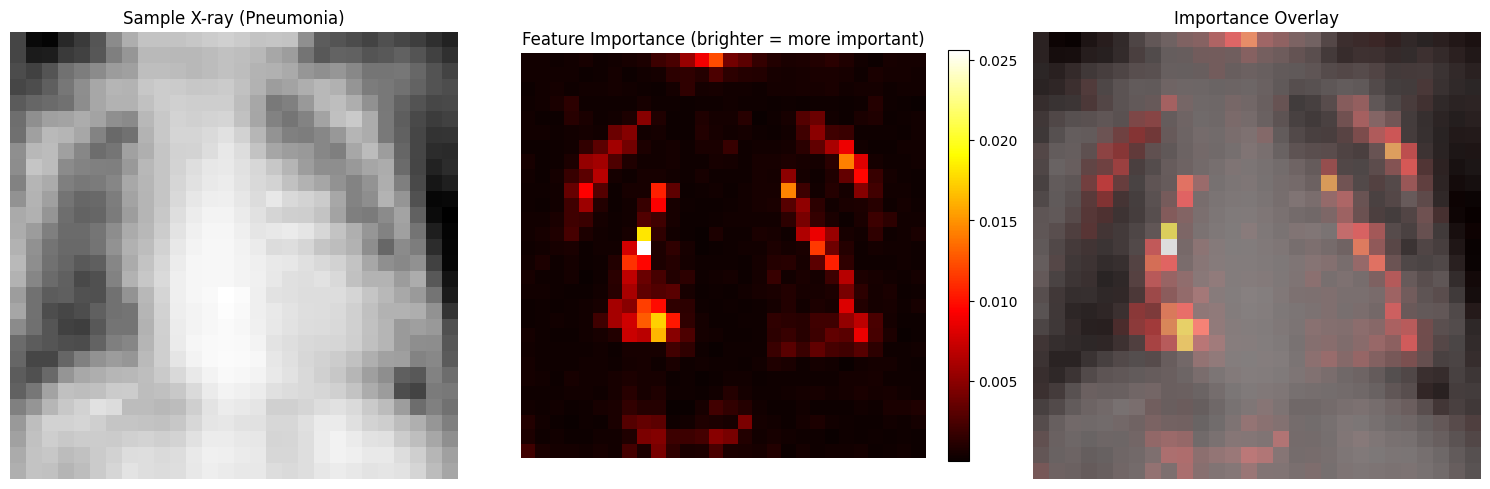

In [8]:
# Get feature importances from Random Forest
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_

# Reshape to 28x28 image
importance_image = importances.reshape(28, 28)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sample X-ray
sample_idx = np.where(y_test == 1)[0][0]  # First pneumonia case
axes[0].imshow(test_dataset.imgs[sample_idx].squeeze(), cmap='gray')
axes[0].set_title('Sample X-ray (Pneumonia)')
axes[0].axis('off')

# Importance heatmap
im = axes[1].imshow(importance_image, cmap='hot')
axes[1].set_title('Feature Importance (brighter = more important)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

# Overlay
axes[2].imshow(test_dataset.imgs[sample_idx].squeeze(), cmap='gray')
axes[2].imshow(importance_image, cmap='hot', alpha=0.5)
axes[2].set_title('Importance Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Takeaways

- **Same CV splitter for fair comparison** - all models evaluated on identical data splits
- **Combine train+val for CV, hold out test** - test set touched only once at the end
- **ROC curves reveal trade-offs** - see how models balance sensitivity vs. specificity
- **Feature importance shows what the model "sees"** - ideally should focus on clinically relevant regions (lung fields), not artifacts
- **Simple models can work well** - logistic regression often competitive with complex methods on medical data